In [37]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn import datasets

from matplotlib.colors import ListedColormap
colormap = ["#30618C", "#21355D", "#229BAE", "#E3E2C3", "#D65638"]
colormap = ListedColormap(colormap)

## Question 1: Understanding Deep Learning Concepts

*a)* The main difference between shallow and deep neural networks is their architecture. A shallow neural network typically has very few, if not just one, hidden layer between the input and output layers. A deep neural network has a more complex architecture with many hidden layers. A deeper network can represent more complex functions due to its many layers that learn progressively on top of previous/earlier layers. This depth and hierarchical feature learning allows for deeper abstraction and pattern/feature capture more easily.

*b)* Activation functions introduce non-linearity into a neural network through the output neurons. Without them, a deep neural network could behave like a simple linear regression model. One common activation function is a *Sigmoid function* that maps outputs to a range (0,1) that is useful for binary classification. The smooth S-curve of the function allows for gradual transition between binary states. Another is *ReLU (Rectified inear Unit)* that maps outputs to only non-negative values. Its piecewise linear nature models non-linear functions by turning off select negative input neurons, selecting only positive necessary neurons.

*c)* In backpropagation, weights are updated based on the gradient of the loss function with respect to each weight. First, the loss function measures the network's error. The gradients with respect to the parameters are then calculated by backpropagation to find how much the weight contributes to the error. The weights are then updated to reduce loss and minimize error.

*d)* Overfitting is when a model learns the training data so well that it includes noise, learning specific data patterns and limiting the ability to generalize with unseen data. One method to prevent overfitting is *Dropout Regularization* where random neurons and their connections are dropped/disabled during training, forcing the model to learn robust representations and not rely too heavily on certain activations. Another is *L2 Regularization* where penalty terms are added to heavy weights, keeping weights small for simpler and more generalizable models.

*e)* High training accuracy and low validation accuracy indicates overfitting - it performs well on training data but has poor generalization on unseen data. A potential step to improve generalization is data augmentation where old data is modified to create "new" data - e.g. rotating galaxy images. Another step could be regularization via dropout, L2/weight decay, or early stopping in order to constrain the model. More generally, either providing more training data or constraining the model.

## Problem 2 - K-means Clustering

In [38]:
def lloyds_algo(data, k, max_iterations = 100, tolerance = 1e-4):

  n_samples, n_features = data.shape

  # choose indices of the dataset vs actual points of the data
  random_indices = np.random.choice(n_samples, size = k, replace = False)
  centers = data[random_indices].copy()

  for iteration in range(max_iterations):
    labels = np.zeros(n_samples, dtype = int) # integers must be used for cluster assignments, avoids float errors

    for i, point in enumerate(data):
      distances = np.linalg.norm(centers - point, axis = 1)
      labels[i] = np.argmin(distances)

    new_centers = np.zeros((k, n_features))
    for i in range(k):
      cluster_set = data[labels == i]
      if len(cluster_set) > 0:
        new_centers[i] = np.mean(cluster_set, axis = 0)
      else:
        new_centers[i] = data[np.random.choice(n_samples)]

    center_shift = np.max(np.linalg.norm(new_centers - centers, axis = 1))
    centers = new_centers

    if center_shift < tolerance:
      print(f"Convergence after {iteration + 1} iterations.")
      break

    if iteration == max_iterations - 1:
      print(f"Convergence not reached after {max_iterations} iterations.")

  clusters = [[] for i in range(k)]
  for i, label in enumerate(labels):
    clusters[label].append(i)

  return clusters, centers, labels

In [39]:
X, Y = datasets.make_blobs(n_samples = 500, n_features = 3, centers = 3, cluster_std = 0.8, random_state = 0)
clusters, centers, labels = lloyds_algo(X, 3)

Convergence after 2 iterations.


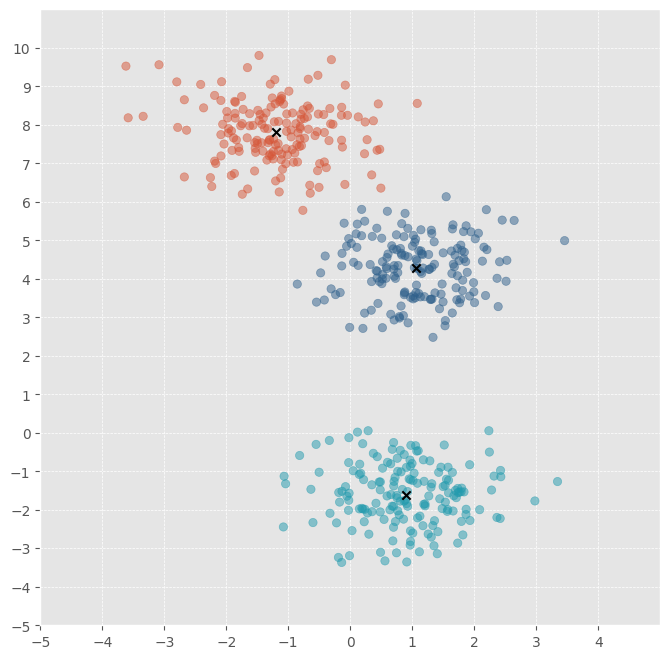

In [40]:
plt.figure(figsize = (8, 8))
plt.style.use('ggplot')
plt.scatter(centers[:, 0], centers[:, 1], c = "black", marker = "x", zorder = 2)
plt.scatter(X[:, 0], X[:, 1], alpha = 0.5, c = Y, cmap = colormap, zorder = 1)
plt.xlim(-5, 5)
plt.ylim(-5, 11)
plt.xticks(np.arange(-5, 5, 1))
plt.yticks(np.arange(-5, 11, 1))
plt.grid(True, which = "both", linestyle = "--", linewidth = 0.5)

For 1 k-clusters:
Convergence after 2 iterations.
For 2 k-clusters:
Convergence after 9 iterations.
For 3 k-clusters:
Convergence after 2 iterations.
For 4 k-clusters:
Convergence after 12 iterations.
For 5 k-clusters:
Convergence after 9 iterations.
For 6 k-clusters:
Convergence after 10 iterations.
For 7 k-clusters:
Convergence after 14 iterations.
For 8 k-clusters:
Convergence after 16 iterations.
For 9 k-clusters:
Convergence after 14 iterations.


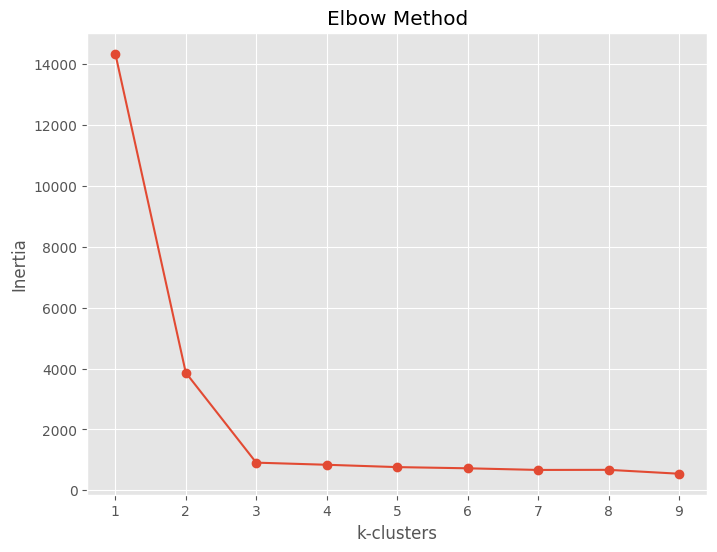

In [41]:
inertias = []
K = range(1, 10)

for k in K:
    print(f"For {k} k-clusters:")
    clusters, centers, labels = lloyds_algo(X, k)
    # compute inertia
    inertia = np.sum(np.linalg.norm(X - centers[labels], axis = 1) ** 2)
    inertias.append(inertia)

plt.figure(figsize = (8, 6))
plt.style.use('ggplot')
plt.plot(K, inertias, marker = "o")
plt.xlabel("k-clusters")
plt.ylabel("Inertia")
plt.title("Elbow Method");